#INFORMACIÓN GENERAL

UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

PROYECTO: IMPLEMENTAR UN CHATBOT PARA UN CRUCERO

#¿QUÉ ES UN CHATBOT?

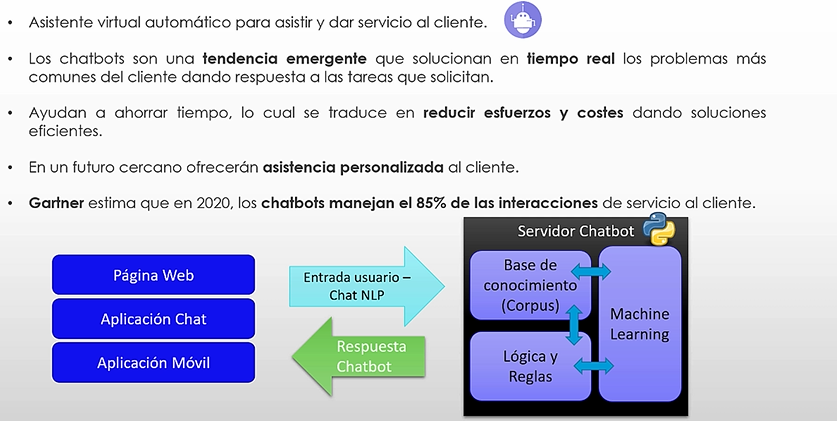

#PROCESO DE IMPLEMENTACIÓN DE UN CHATBOT

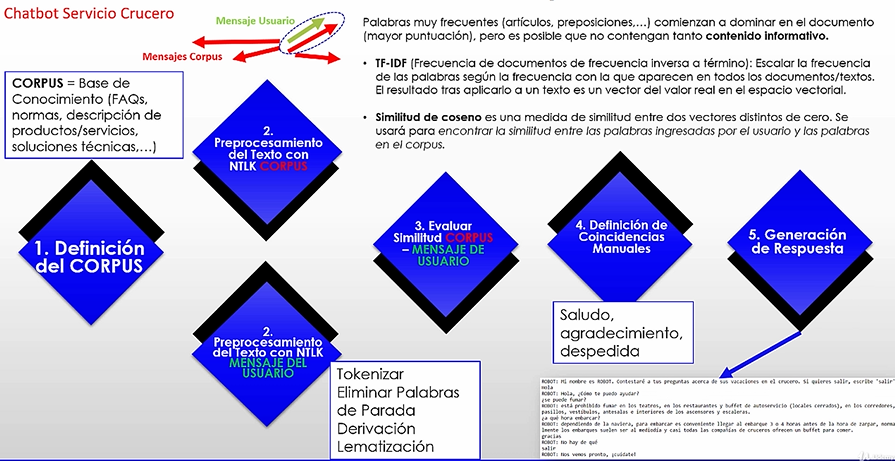

##Term Frequency – Inverse Document Frequency (TF-IDF)

**1. Term Frequency – Inverse Document Frequency (TF-IDF)**<br>
Is a term weighting method that calculates information amount by its occurrence probability [5]. The calculation is shown in below Equation (1).

$TFIDF_{t,d} = TF_{t,d} \times IDF_{t,d}$

Where:<br>
$TF_{t,d}$ : normalized term frequency of term t in document d <br>
$IDF_{t,d}$ : inverse document frequency of term t in all documents<br>

**1.1. Term Frequency**<br>
Term Frequency is the number of term t that exists in a document d [6]. In a normalized form, it is notated as Equation (2) shows below where the most used K value is 0.5.

$TF_{t,d} = K + (1-K) \times (\frac{f_{t,d}}{max(f_{t',d}:t'\in d)})$

Where:<br>
$TF_{t,d}$ : normalized term frequency of term t in document d<br>
$K$ : 0,5 is used, so the term frequency of term t will be between 0,5 to 1<br> $f_{t,d}$ : number of term t in document d<br>
$max(f_{t',d} : t'∈d)$ : number of term t', where t' is the most word in document d

**1.2. Inverse Document Frequency**<br>
Inverse Document Frequency (IDF) indicates how common or rare a term is in all documents by basically counting the number of documents that have term t [7]. It is a common technique used in information retrieval.<br>

$IDF_{t,d} = log(\frac{D}{df_{t}})$

Where:<br>
$IDF_{t,d}$ : inverse document frequency of term t in all documents<br>
$D$ : number of documents in the training set<br>
$df_{t}$ : number of documents in the training set having term t

    https://www.atlantis-press.com/proceedings/issat-21/125963774

##Cosine Similarity

Cosine similarity is a metric used to measure how similar the documents are irrespective of their size. Mathematically, it measures the cosine of the angle between two vectors projected in a multi-dimensional space.

    https://www.machinelearningplus.com/nlp/cosine-similarity/

**Cosine Similarity Formula**

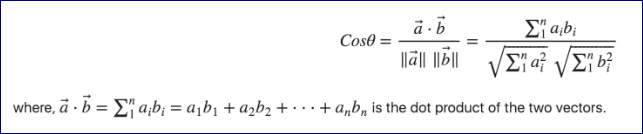

#IMPLEMENTACIÓN DE UN CHATBOT PARA CRUCEROS

##Librerías

*Importar* las librerías necesarias para el procesamiento de lenguaje natural

In [ ]:
import string
import random
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
nltk.download('punkt') # -- Instalar módulo punkt
nltk.download('wordnet') # -- Instalar módulo wordnet
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Instalar la librería que convierte texto a voz y lo almacena en un archivo

In [ ]:
!pip install gTTS

In [ ]:
from gtts import gTTS # -- Para convertir texto a archivo de tipo sonido
from IPython.display import Audio # -- Para reporducir archivos de tipo sonido
import time

##1 Definición del CORPUS

In [ ]:
archivo = open('Corpus_crucero.txt','r', encoding='latin-1', errors='ignore')
raw = archivo.read()

##2 Preprocesamiento del Texto

###2a Preprocesamiento del Texto con NLTK CORPUS

In [ ]:
raw=raw.lower() # -- convertir a minúsculas

sent_tokens = nltk.sent_tokenize(raw) # -- Convierte el CORPUS a una lista de sentencias
word_tokens = nltk.word_tokenize(raw) # -- Convierte el CORPUS a una lista de palabras
lemmer = nltk.stem.WordNetLemmatizer() # -- Crear objeto para lematizar

# -- Función para generar lista de tokens lematizados
def LemTokens(tokens):
  return [lemmer.lemmatize(token) for token in tokens]

# -- Recuperar como un diccionario los signos de puntuación a remover
remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
# -- Función de lematización removiendo los signos de puntuación
def LemNormalize(text):
  return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))

###2b Preprocesamiento del Texto con NLTK Mensaje de usuario

In [ ]:
def preprocesamiento_texto_usuario(user_response):
  # robo_response = ''
  sent_tokens.append(user_response) # -- Añade al final del CORPUS la respuesta del usuario
  TfidfVec = TfidfVectorizer(tokenizer=LemNormalize, stop_words = stopwords.words('spanish'))
  tfidf = TfidfVec.fit_transform(sent_tokens)
  return tfidf

##3 Evaluar similitud MENSAJE USUARIO - CORPUS

In [ ]:
# -- Función para determinar la similitud del texto insertado y el CORPUS
def response(user_response):
  robo_response = ''
  tfidf = preprocesamiento_texto_usuario(user_response)
  # 3 Evaluar similitud de coseno entre mensaje de usuario (tfidf[-1]) y el CORPUS (tfidf)
  vals = cosine_similarity(tfidf[-1], tfidf)
  print(vals)
  idx = vals.argsort()[0][-2]
  print(idx)
  flat = vals.flatten()
  print(flat)
  flat.sort()
  print(flat)
  req_tfidf = flat[-2]

  if (req_tfidf == 0):
    robo_response = robo_response+"Lo siento, no te entendí. Póngase en contacto con el personal asistencial"
  else:
    robo_response = robo_response + sent_tokens[idx]
  return robo_response


##4 Definición de coincidencias manual

In [ ]:
SALUDOS_INPUTS = ("hola","buenas", "saludos", "qué tal", "hey", "buenos días")
SALUDOS_OUTPUTS = ["Hola", "Hola, ¿Qué tal?", "Hola, ¿Cómo te puedo ayudar?", "Hola, encantado de hablar contigo"]

def saludos(sentence):
  for word in sentence.split():
    if word.lower() in SALUDOS_INPUTS:
      return random.choice(SALUDOS_OUTPUTS)

##5 Generación de respuesta

Módulo para convertir texto a un archivo de sonido (voz)

In [ ]:
def reproducir(texto):
  lenguaje = "es"
  gtts_object = gTTS(text = texto, lang = lenguaje)
  gtts_object.save("mensaje.mp3")
  audio = Audio("mensaje.mp3", autoplay=True, )
  display(audio)

Programa principal

In [ ]:
# -- PROGRAMA PRINCIPAL
flag = True
reproducir('Hola, contestaré a tus preguntas acerca de tus vacaciones en el crucero.')
time.sleep(6)
reproducir('Si ya no deseas continuar, escribe salir, adios o chau')
time.sleep(4)
while (flag == True):
  # -- Solicitar que el usuario ingrese algún texto
  user_response = input()
  user_response = user_response.lower() # -- Convertir a minúsculas

  if (user_response != 'salir') and (user_response != 'adios') and (user_response != 'chau'):
    if (user_response=='gracias' or user_response=='muchas gracias'):
      flag = True
      reproducir('No hay de qué')
      time.sleep(2)
    else:
      if (saludos(user_response) != None):
        reproducir(saludos(user_response))
        time.sleep(2)
      else:
        reproducir(response(user_response))
        time.sleep(2)
        sent_tokens.remove(user_response) # -- Para eliminar del CORPUS la respuesta del usuario y volver a evaluar con el CORPUS limpio
  else:
    flag = False
    reproducir('Nos vemos pronto, ¡Cuídate!')
    time.sleep(2)


salir


##Ejercicios


Implementar un Chatbot para la atención en la Escuela Profesional de Ingeniería Informática y de Sistemas.

